<a href="https://colab.research.google.com/github/atanilson/Comp702/blob/main/Comp702_Modular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Libraries

In [ ]:
# Geeting Files from GIt HUB

In [ ]:
"""
from functools import partial
import requests
from pathlib import Path

SCRIPTS_FOLDER = Path("scripts")
SCRIPTS_FOLDER.mkdir(parents=True,
                     exist_ok=True)

# URl of raw file in git hub
get_data_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/get_data.py"
CNN_Model1_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/CNN_Model1.py"
data_setup_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/data_setup.py"
engine_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/engine.py"
Main_script_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/Main_script.py"
utils_url = "https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/utils.py"

request = requests.get(get_data_url)
with open("scripts/get_data.py","wb") as f:
  f.write(request.content)
"""

In [1]:
%%capture
!mkdir scripts
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/get_data.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/CNN_Model1.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/data_setup.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/engine.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/Main_script.py
!wget https://raw.githubusercontent.com/atanilson/Comp702/refs/heads/main/scripts/utils.py
!mv get_data.py CNN_Model1.py data_setup.py engine.py Main_script.py utils.py scripts/
#!unzip scripts.zip

In [2]:
import os
import torch
from scripts import data_setup, engine, utils, get_data
from timeit import default_timer as timer

from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
device

'cuda'

In [4]:
get_data.download()

In [5]:
# Setup hyperparameters
NUM_EPOCHS = 150
BATCH_SIZE = 32
TEST_SPLIT = 0.2
HIDDEN_UNITS = 10
LEARNING_RATE = 0.001

# Setup directories
data_dir = "data/EuroSAT_RGB"

size_cut = 224

# Create tranforms Train
transform_train = transforms.Compose([
    transforms.Resize(size_cut),
    transforms.RandomResizedCrop(size_cut),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    #transforms.RandomHorizontalFlip(),
    #****transforms.RandomRotation(10),
    #transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create tranforms test
transform_test = transforms.Compose([
    transforms.Resize(size_cut),
    transforms.CenterCrop(size_cut),
    #transforms.RandomHorizontalFlip(),
    #****transforms.RandomRotation(10),
    #transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


## Test transform onlr resise and normilize


# Create dataloaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders2(dataset_dir="data/EuroSAT_RGB",
                                                                               train_transform=transform_train,
                                                                               test_transform=transform_test,
                                                                               batch_size=BATCH_SIZE,
                                                                               test_split = TEST_SPLIT,
                                                                               #random_seed = 42,
                                                                               #num_workers = 1
                                                                               )

In [6]:
## MODEL

###model = - instatiate wterever
from torchvision.models import resnet50
from scripts import CNN_Model1

model_2 = resnet50(weights=None)
model_2.fc = torch.nn.Linear(in_features=model_2.fc.in_features, out_features=len(class_names))
model_2 = model_2.to(device)

"""
model_1 = CNN_Model1.CNN_Model1(
    input_shape=3,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)
"""

'\nmodel_1 = CNN_Model1.CNN_Model1(\n    input_shape=3,\n    hidden_units=10,\n    output_shape=len(class_names)\n).to(device)\n'

In [ ]:
## LOSS FUNCTION OPTMIZER
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=LEARNING_RATE)

start_time = timer()
trained_model, results = engine.train(model=model_2, #Change to train next time I will change on the script
             train_dataloader = train_dataloader,
             test_dataloader = test_dataloader,
             loss_fn = loss_fn,
             optimizer = optimizer,
             epochs = NUM_EPOCHS,
             device=device)
end_time = timer()

time_taken = end_time-start_time

print(f"Total training time:{end_time-start_time:.3f} seconds")

  0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.9260, Train Acc: 30.7824% | Test loss:1.6746, Test acc: 39.5587%
Epoch: 1 | Train loss: 1.5330, Train Acc: 46.5648% | Test loss:1.3426, Test acc: 53.0510%
Epoch: 2 | Train loss: 1.3409, Train Acc: 52.5602% | Test loss:1.5031, Test acc: 45.6546%
Epoch: 3 | Train loss: 1.2788, Train Acc: 54.4537% | Test loss:1.1293, Test acc: 62.0932%
Epoch: 4 | Train loss: 1.1954, Train Acc: 57.4074% | Test loss:1.0694, Test acc: 62.8575%
Epoch: 5 | Train loss: 1.1385, Train Acc: 59.3750% | Test loss:0.9941, Test acc: 65.1566%
Epoch: 6 | Train loss: 1.0862, Train Acc: 61.6250% | Test loss:0.9480, Test acc: 67.6220%
Epoch: 7 | Train loss: 1.0456, Train Acc: 62.8565% | Test loss:0.8972, Test acc: 68.0473%
Epoch: 8 | Train loss: 1.0234, Train Acc: 63.6898% | Test loss:0.8630, Test acc: 69.1753%
Epoch: 9 | Train loss: 0.9801, Train Acc: 65.3981% | Test loss:0.8174, Test acc: 72.3681%
Epoch: 10 | Train loss: 0.9397, Train Acc: 67.0324% | Test loss:0.7917, Test acc: 72.4297%
Epoch: 11

In [ ]:
type(trained_model)

scripts.CNN_Model1.CNN_Model1

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

save_dir = "./drive/My Drive/Colab Notebooks/Comp702/Models/Retrained"

Mounted at /content/drive


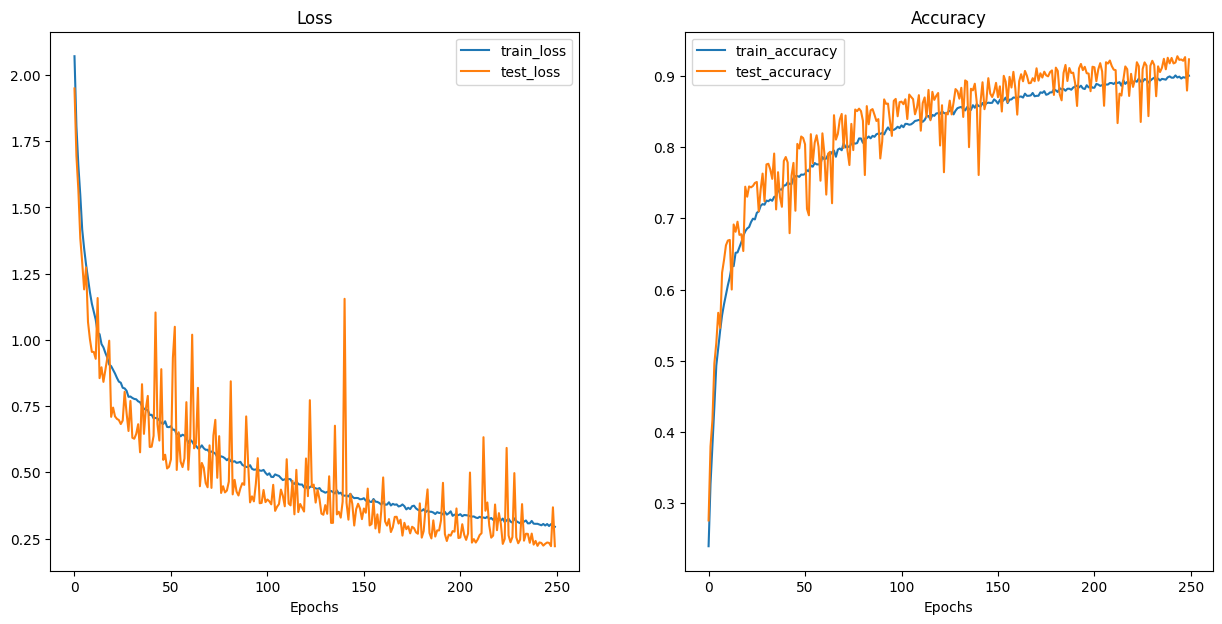

In [ ]:
utils.plot_loss_curves(results)

In [ ]:
#
utils.save_model(model=trained_model,
                 target_dir = save_dir,
                 model_name="RESNET50_0001_SDG-RGB_B32_NW_EP250_S224.pth")

#
utils.save_results(results=results,
                   optimizer="SDG",
                   lr="0_001",
                   model="RESNET50_RGB_B32_NW_EP250_S224",
                   time=time_taken,
                   save_dir=save_dir)

[INFO] Saving model to: drive/My Drive/Colab Notebooks/Comp702/Models/Retrained/RESNET50_0001_SDG-RGB_B32_NW_EP250.pth
Saving to ./drive/My Drive/Colab Notebooks/Comp702/Models/RetrainedRESNET50_RGB_B32_NW_EP250_SDG_0_001.csv


In [ ]:
#
utils.save_results(results=results,
                   optimizer="ADAMmmmm",
                   lr="0_001",
                   model="MODEL_1_RGB",
                   time=time_taken,
                   save_dir=save_dir)